In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"richavasudeva","key":"431836916cac4626117dc00e2b6adc40"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d swaroopkml/cifar10-pngs-in-folders

Dataset URL: https://www.kaggle.com/datasets/swaroopkml/cifar10-pngs-in-folders
License(s): unknown
100% 140M/140M [00:01<00:00, 78.7MB/s]



In [5]:
!unzip -q cifar10-pngs-in-folders.zip -d cifar10

In [6]:
import os

dataset_path = "/content/cifar10"

print(os.listdir(dataset_path))

['cifar10']


In [7]:
import os

for root, dirs, files in os.walk(dataset_path):
    print(root)
    print("Folders:", dirs[:10])
    print("Files:", len(files))
    print("-"*50)

/content/cifar10
Folders: ['cifar10']
Files: 0
--------------------------------------------------
/content/cifar10/cifar10
Folders: ['cifar10']
Files: 0
--------------------------------------------------
/content/cifar10/cifar10/cifar10
Folders: ['train', 'test']
Files: 0
--------------------------------------------------
/content/cifar10/cifar10/cifar10/train
Folders: ['automobile', 'cat', 'truck', 'deer', 'horse', 'ship', 'bird', 'frog', 'airplane', 'dog']
Files: 0
--------------------------------------------------
/content/cifar10/cifar10/cifar10/train/automobile
Folders: []
Files: 5000
--------------------------------------------------
/content/cifar10/cifar10/cifar10/train/cat
Folders: []
Files: 5000
--------------------------------------------------
/content/cifar10/cifar10/cifar10/train/truck
Folders: []
Files: 5000
--------------------------------------------------
/content/cifar10/cifar10/cifar10/train/deer
Folders: []
Files: 5000
----------------------------------------------

In [8]:
import os

train_dir = "/content/cifar10/cifar10/cifar10/train"
test_dir = "/content/cifar10/cifar10/cifar10/test"

print("Train Classes:", os.listdir(train_dir))
print("Test Classes:", os.listdir(test_dir))

Train Classes: ['automobile', 'cat', 'truck', 'deer', 'horse', 'ship', 'bird', 'frog', 'airplane', 'dog']
Test Classes: ['automobile', 'cat', 'truck', 'deer', 'horse', 'ship', 'bird', 'frog', 'airplane', 'dog']


In [9]:
# counting images per classes
from collections import defaultdict
import os

class_counts = defaultdict(int)

for cls in sorted(os.listdir(train_dir)):
    cls_path = os.path.join(train_dir, cls)

    if os.path.isdir(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

print("Training Set Distribution\n")

for cls, count in class_counts.items():
    print(f"{cls:<12} : {count}")

Training Set Distribution

airplane     : 5000
automobile   : 5000
bird         : 5000
cat          : 5000
deer         : 5000
dog          : 5000
frog         : 5000
horse        : 5000
ship         : 5000
truck        : 5000


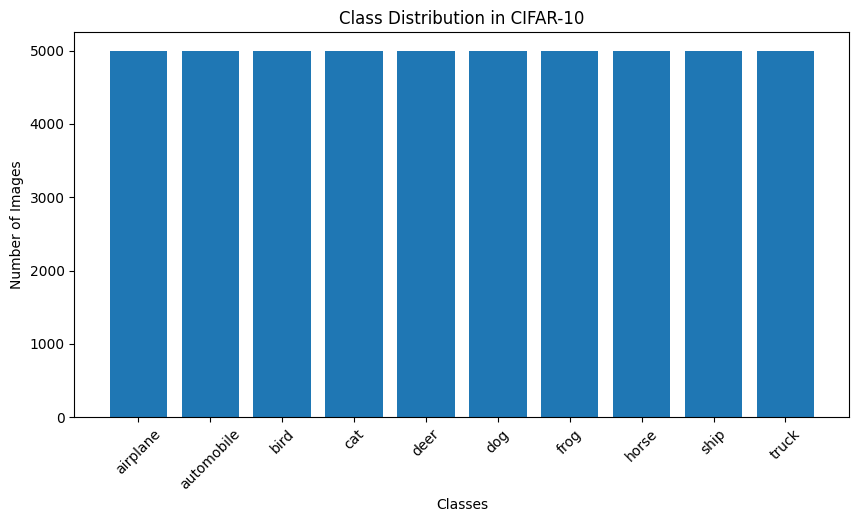

In [10]:
# visualising class distributuion
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(class_counts.keys(),
        class_counts.values())

plt.title("Class Distribution in CIFAR-10")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.show()

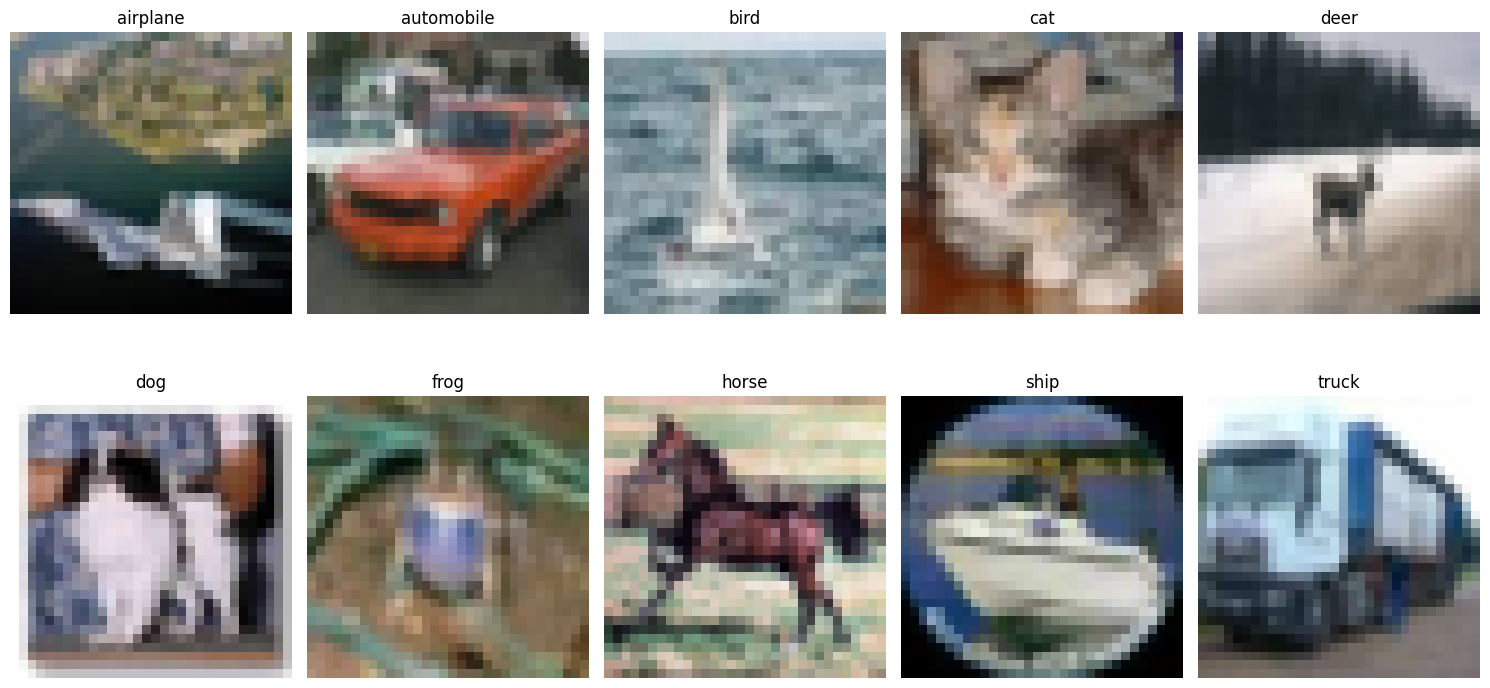

In [11]:
# displaying images
from PIL import Image
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(15,8))

classes = sorted(os.listdir(train_dir))

for i, cls in enumerate(classes):

    img_file = random.choice(
        os.listdir(os.path.join(train_dir, cls))
    )

    img_path = os.path.join(
        train_dir,
        cls,
        img_file
    )

    img = Image.open(img_path)

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# data augmentation
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)

Using Device: cuda


In [14]:
# loading dataset
train_dataset = datasets.ImageFolder(
    root="/content/cifar10/cifar10/cifar10/train",
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root="/content/cifar10/cifar10/cifar10/test",
    transform=test_transform
)

print("Training Images:", len(train_dataset))
print("Testing Images :", len(test_dataset))

Training Images: 50000
Testing Images : 10000


In [15]:
# creating data loaders
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print("Train Batches:", len(train_loader))
print("Test Batches :", len(test_loader))

Train Batches: 391
Test Batches : 79


In [16]:
images, labels = next(iter(train_loader))

print("Image Shape :", images.shape)
print("Label Shape :", labels.shape)

Image Shape : torch.Size([128, 3, 32, 32])
Label Shape : torch.Size([128])


In [17]:
# baseline cnn
class BaselineCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(128*4*4,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,10)
        )

    def forward(self,x):

        x = self.features(x)

        x = x.view(x.size(0),-1)

        x = self.classifier(x)

        return x

In [18]:
baseline_model = BaselineCNN().to(device)

print(baseline_model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [19]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    baseline_model.parameters(),
    lr=0.001
)

In [20]:
def train_model(model,
                train_loader,
                criterion,
                optimizer,
                epochs=10):

    train_losses = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        train_losses.append(epoch_loss)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {epoch_loss:.4f}"
        )

    return train_losses

In [21]:
# training baseline cnn
baseline_losses = train_model(
    baseline_model,
    train_loader,
    criterion,
    optimizer,
    epochs=5
)

Epoch [1/5] Loss: 1.6716
Epoch [2/5] Loss: 1.2983
Epoch [3/5] Loss: 1.1175
Epoch [4/5] Loss: 1.0110
Epoch [5/5] Loss: 0.9420


In [22]:
# evaluation function
def evaluate_model(model, loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs,1)

            y_true.extend(labels.numpy())

            y_pred.extend(predicted.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )

    return acc, precision, recall, f1

In [24]:
baseline_acc, baseline_prec, baseline_rec, baseline_f1 = evaluate_model(
    baseline_model,
    test_loader
)
print("_______BASELINE CNN________")
print("Accuracy :", baseline_acc)
print("Precision:", baseline_prec)
print("Recall   :", baseline_rec)
print("F1 Score :", baseline_f1)

_______BASELINE CNN________
Accuracy : 0.6947
Precision: 0.7126927564568807
Recall   : 0.6947
F1 Score : 0.6916793674249122


In [25]:
class SEBlock(nn.Module):

    def __init__(self, channels, reduction=16):
        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):

        batch_size, channels, _, _ = x.size()

        y = nn.functional.adaptive_avg_pool2d(
            x, 1
        ).view(batch_size, channels)

        y = self.fc(y)

        y = y.view(batch_size, channels, 1, 1)

        return x * y

In [26]:
# CNN+SE Block
class CNN_SE(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.se1 = SEBlock(32)

        self.conv2 = nn.Sequential(
            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.se2 = SEBlock(64)

        self.conv3 = nn.Sequential(
            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.se3 = SEBlock(128)

        self.fc = nn.Sequential(
            nn.Linear(128*4*4,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,10)
        )

    def forward(self,x):

        x = self.conv1(x)
        x = self.se1(x)

        x = self.conv2(x)
        x = self.se2(x)

        x = self.conv3(x)
        x = self.se3(x)

        x = x.view(x.size(0),-1)

        x = self.fc(x)

        return x

In [27]:
# se model
se_model = CNN_SE().to(device)

print(se_model)

CNN_SE(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (se1): SEBlock(
    (fc): Sequential(
      (0): Linear(in_features=32, out_features=2, bias=True)
      (1): ReLU()
      (2): Linear(in_features=2, out_features=32, bias=True)
      (3): Sigmoid()
    )
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (se2): SEBlock(
    (fc): Sequential(
      (0): Linear(in_features=64, out_features=4, bias=True)
      (1): ReLU()
      (2): Linear(in_features=4, out_features=64, bias=True)
      (3): Sigmoid()
    )
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=

In [28]:
# loss and optimization
criterion_se = nn.CrossEntropyLoss()

optimizer_se = optim.Adam(
    se_model.parameters(),
    lr=0.001
)

In [29]:
# training se model
se_losses = train_model(
    se_model,
    train_loader,
    criterion_se,
    optimizer_se,
    epochs=5
)

Epoch [1/5] Loss: 1.7862
Epoch [2/5] Loss: 1.4633
Epoch [3/5] Loss: 1.3002
Epoch [4/5] Loss: 1.1713
Epoch [5/5] Loss: 1.0683


In [30]:
# evaluation se block
se_acc, se_prec, se_rec, se_f1 = evaluate_model(
    se_model,
    test_loader
)

print("======= CNN + SE =======")

print("Accuracy :", se_acc)
print("Precision:", se_prec)
print("Recall   :", se_rec)
print("F1 Score :", se_f1)

======= CNN + SE =======
Accuracy : 0.673
Precision: 0.6882138307015471
Recall   : 0.673
F1 Score : 0.6753362062562112


In [32]:
# confusion matrix
import seaborn as sns

def plot_confusion_matrix(model):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs,1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true,y_pred)

    plt.figure(figsize=(10,8))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d'
    )

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [33]:
# comparison table
import pandas as pd

comparison = pd.DataFrame({

    "Model":[
        "Baseline CNN",
        "CNN + SE"
    ],

    "Accuracy":[
        baseline_acc,
        se_acc
    ],

    "Precision":[
        baseline_prec,
        se_prec
    ],

    "Recall":[
        baseline_rec,
        se_rec
    ],

    "F1 Score":[
        baseline_f1,
        se_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline CNN,0.6947,0.712693,0.6947,0.691679
1,CNN + SE,0.6730,0.688214,0.6730,0.675336


In [34]:
print("\n========== FINAL RESULTS ==========")

print(f"Baseline CNN Accuracy : {baseline_acc*100:.2f}%")
print(f"Baseline CNN Precision: {baseline_prec*100:.2f}%")
print(f"Baseline CNN Recall   : {baseline_rec*100:.2f}%")
print(f"Baseline CNN F1 Score : {baseline_f1*100:.2f}%")

print("\n-----------------------------------")

print(f"CNN + SE Accuracy     : {se_acc*100:.2f}%")
print(f"CNN + SE Precision    : {se_prec*100:.2f}%")
print(f"CNN + SE Recall       : {se_rec*100:.2f}%")
print(f"CNN + SE F1 Score     : {se_f1*100:.2f}%")


========== FINAL RESULTS ==========
Baseline CNN Accuracy : 69.47%
Baseline CNN Precision: 71.27%
Baseline CNN Recall   : 69.47%
Baseline CNN F1 Score : 69.17%

-----------------------------------
CNN + SE Accuracy     : 67.30%
CNN + SE Precision    : 68.82%
CNN + SE Recall       : 67.30%
CNN + SE F1 Score     : 67.53%


In [35]:
improvement = (se_acc - baseline_acc) * 100

print(f"Baseline Accuracy : {baseline_acc*100:.2f}%")
print(f"SE Accuracy       : {se_acc*100:.2f}%")
print(f"Improvement       : {improvement:.2f}%")

Baseline Accuracy : 69.47%
SE Accuracy       : 67.30%
Improvement       : -2.17%
